In [51]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, InputLayer, Dense

In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
import pandas as pd
df= pd.read_csv('student-mat.csv',sep=';')
df.head(20)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [54]:
df.shape

(395, 33)

In [55]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


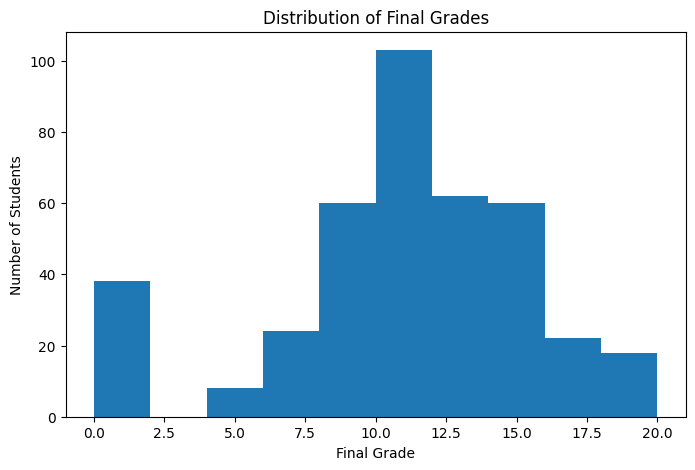

In [56]:
plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=10)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

In [57]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

cat_cols = df.select_dtypes(include='object').columns.tolist()
df_enc = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

In [58]:
x = df.drop('G3', axis=1)
y = df['G3']
print("\nFeature Shape:", x.shape)
print("Target Shape:", y.shape)


Feature Shape: (395, 32)
Target Shape: (395,)


In [59]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f"Train: {x_train.shape[0]}, Test: {x_test.shape[0]}")

Train: 316, Test: 79


In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Re-create x from the encoded DataFrame df_enc
x_numeric = df_enc.drop('G3', axis=1)

# Re-split the data using the numerically encoded features
# This ensures x_train and x_test contain only numerical values
x_train, x_test, y_train, y_test = train_test_split(x_numeric, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

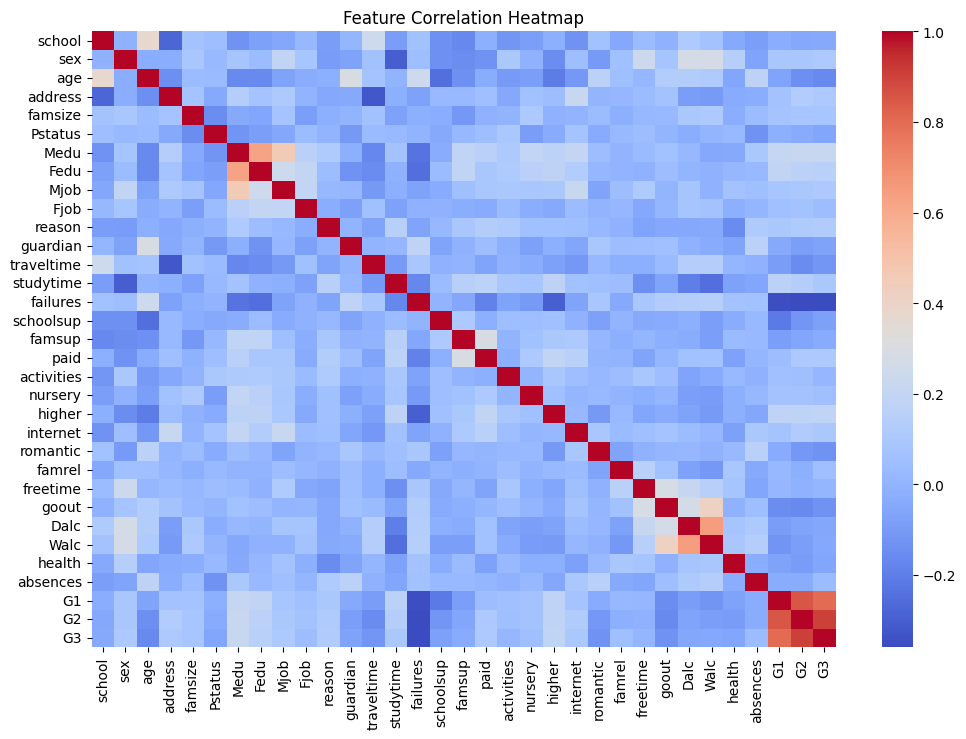

In [61]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df_enc.corr(),cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

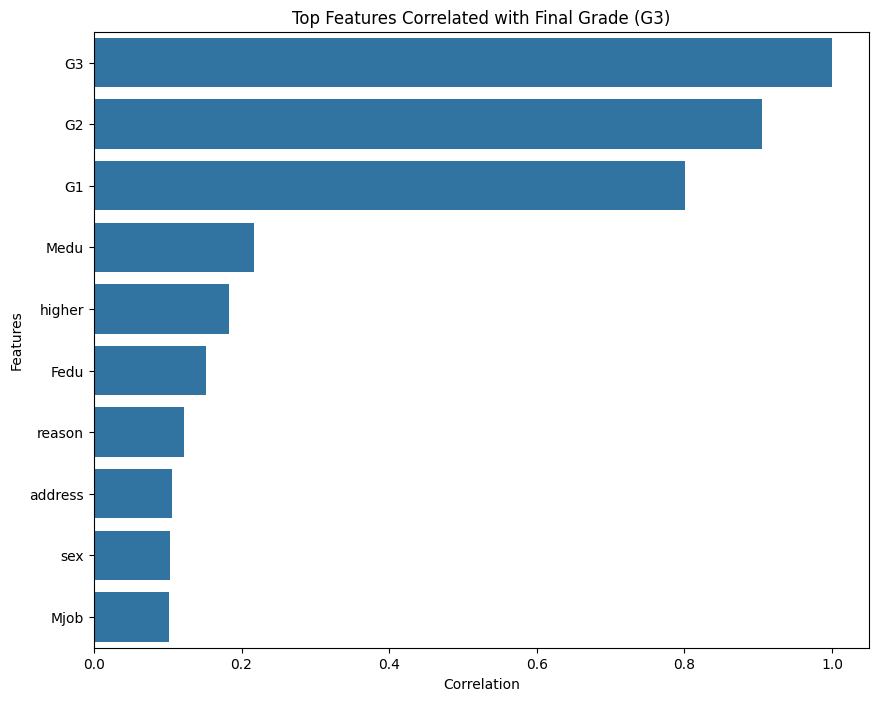

In [62]:
plt.figure(figsize=(10,8))

top_corr = df_enc.corr()['G3'].sort_values(ascending=False)

sns.barplot(x=top_corr.values[:10], y=top_corr.index[:10])

plt.title("Top Features Correlated with Final Grade (G3)")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

In [63]:
model = Sequential([
    Input(shape=(32, )),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
   ])

In [64]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=32,#Understanding mini-batch gradient descent here
    validation_split=0.2 # 20% of the data is used for validation
)

test_loss, test_mae = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

predictions = model.predict(x_test[:5])

print("\nPredictions for the first 5 test samples:")
for i in range(5):
    predicted_grade = predictions[i][0]
    print(f"Actual: {y_test.iloc[i]} | Predicted: {predicted_grade:.2f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 111.7458 - mae: 9.6471 - val_loss: 95.1932 - val_mae: 9.1117
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 85.4455 - mae: 8.4854 - val_loss: 69.2146 - val_mae: 7.7793
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 60.6968 - mae: 7.1098 - val_loss: 44.2391 - val_mae: 6.1458
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 37.4146 - mae: 5.4688 - val_loss: 24.3403 - val_mae: 4.3492
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 20.7511 - mae: 3.8337 - val_loss: 13.4412 - val_mae: 2.9404
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 12.7775 - mae: 2.7380 - val_loss: 10.9355 - val_mae: 2.3290
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 10.6461 - mae: 2.3256 - val_loss: 10.2179 - val_mae: 2.2490
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 8.8356 - mae: 2.1146 - val_loss: 8.8621 - val_mae: 2.1589
Epoch 9/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 7.1421 -

In [65]:
from sklearn.metrics import r2_score

predictions = model.predict(x_test)
r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step 
R2 Score: 0.6672675609588623


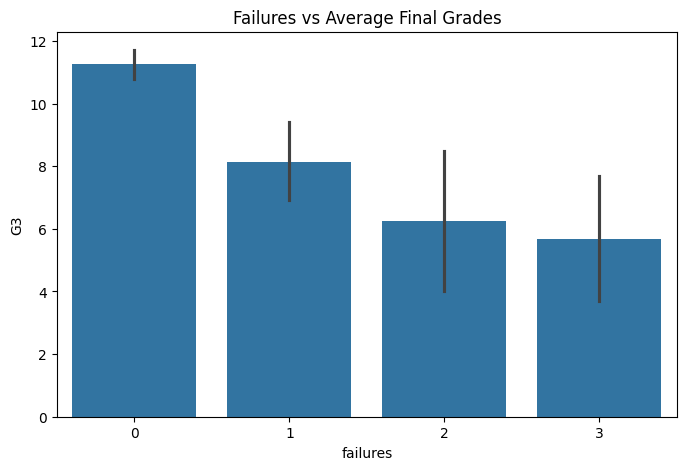

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(x='failures', y='G3', data=df)
plt.title("Failures vs Average Final Grades")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


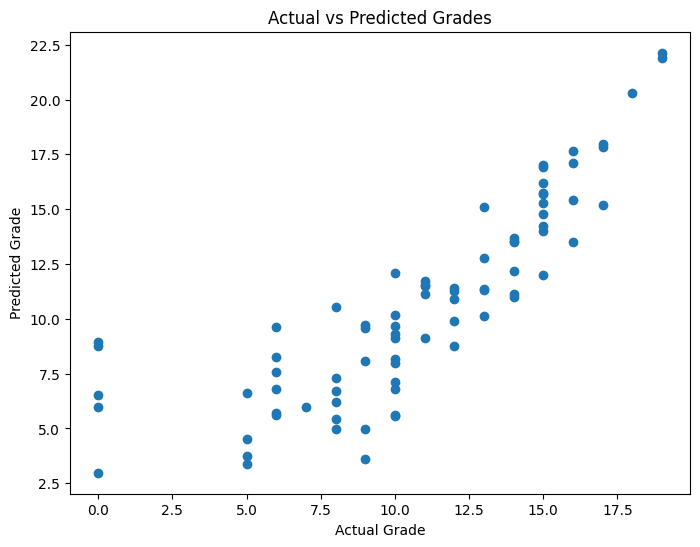

In [67]:
predictions = model.predict(x_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted Grades")

plt.show()